# Leaching data generator

Generates the input vectors and simulates the leaching reactor, writing full-resolution `h5` files
for `TimesFM3-Forecast.ipynb`.

Model (time unit = minutes): states `x = [C_Cu_aq, C_H, C_Cu_s]`, inputs
`u = [q_H, F, C_H_in, C_Cu_s_in]`, fixed `V, k, gamma`.

Inputs: `q_H` gets step pulses; `F`, `C_H_in` and `C_Cu_s_in` get trapezoid ramp-up / hold /
ramp-down events. One input moves at a time, each event is held long enough for the states to
settle, and events are separated by nominal baseline.


In [ ]:
import os, numpy as np, h5py
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

rng = np.random.default_rng(42)

# Leaching model
# States x = [C_Cu_aq, C_H, C_Cu_s];  Inputs u = [q_H, F, C_H_in, C_Cu_s_in];  fixed V, k, gamma.
# q_H = acid dosing [mol/min] (manipulated),  F = slurry flow [m^3/min],
# C_H_in = feed acid conc,  C_Cu_s_in = ore grade (feed solid Cu).
V, k, gamma = 10.0, 0.05, 1.0

def f(x, u):
    C_Cu_aq, C_H, C_Cu_s = x
    q_H, F, C_H_in, C_Cu_s_in = u
    r = k * C_H * C_Cu_s
    return np.array([
        -(F / V) * C_Cu_aq + r,
        (F / V) * (C_H_in - C_H) - gamma * r + q_H / V,
        (F / V) * (C_Cu_s_in - C_Cu_s) - r,
    ])

pH = lambda C_H: -np.log10(C_H)        # pH measurement

In [2]:
# Time base
# tau = V/F = 10 min (residence time). raw dt = 0.1 min (6 s) -> 100 raw steps per tau.
# 60k raw steps = 6000 min = 100 h.
DT_MIN, N, TAU = 0.1, 60_000, 100
t_min = np.arange(N) * DT_MIN

# Input event definitions
# q_H -> step pulses. F / C_H_in / C_Cu_s_in -> trapezoid ramp/hold/ramp.
# Sign is randomised, and |magnitude| = delta*(1 + U(0, variance)).
INPUTS = {
    "q_H":       dict(base=2.5,  delta=1.00, variance=0.2, count=4, kind="step"),
    "F":         dict(base=1.0,  delta=0.35, variance=0.3, count=6, kind="ramp"),
    "C_H_in":    dict(base=0.05, delta=0.03, variance=0.3, count=6, kind="ramp"),
    "C_Cu_s_in": dict(base=8.0,  delta=2.00, variance=0.3, count=6, kind="ramp"),
}
DURATION_RANGE = (8 * TAU, 15 * TAU)   # 8-15 tau per event
RAMP_FRACTION  = 0.15                  # trapezoids only (ignored for steps)
MIN_GAP        = 5 * TAU               # >= 5 tau of nominal baseline between events

# schedule non-overlapping events
events = [n for n, c in INPUTS.items() for _ in range(c["count"])]
rng.shuffle(events)
durations = rng.integers(DURATION_RANGE[0], DURATION_RANGE[1] + 1, size=len(events))
total_base = N - int(durations.sum())
num_gaps = len(events) + 1
if total_base < MIN_GAP * num_gaps:
    raise ValueError("Not enough room for the requested events with MIN_GAP baseline between them "
                     "- reduce counts/durations or increase N.")
gaps = np.floor(rng.dirichlet(np.ones(num_gaps)) * (total_base - MIN_GAP * num_gaps)).astype(int) + MIN_GAP
gaps[-1] += total_base - gaps.sum()            # absorb rounding remainder

schedule = []                                   # (name, start, end, duration)
pos = gaps[0]
for i, name in enumerate(events):
    dur = int(durations[i])
    schedule.append((name, pos, pos + dur, dur))
    pos += dur + gaps[i + 1]
assert pos == N

# build input vectors: baseline + step / trapezoid perturbations
vectors = {n: np.full(N, c["base"]) for n, c in INPUTS.items()}
flags   = {n: np.zeros(N) for n in INPUTS}      # 1 across the whole event
for name, start, end, dur in schedule:
    cfg = INPUTS[name]
    mag = cfg["delta"] * (1 + rng.uniform(0, cfg["variance"])) * rng.choice([1, -1])
    if cfg["kind"] == "step":
        vectors[name][start:end] = cfg["base"] + mag
    else:
        up = max(1, round(dur * RAMP_FRACTION)); hold = dur - 2 * up
        pert = np.concatenate([np.linspace(0, mag, up), np.full(hold, mag), np.linspace(mag, 0, up)])
        vectors[name][start:end] = cfg["base"] + pert
    flags[name][start:end] = 1

overlap = np.vstack(list(flags.values())).sum(axis=0)
assert overlap.max() <= 1, "events overlap - scheduling bug"
print(f"{len(events)} events, one active at a time (max simultaneous = {int(overlap.max())})")

22 events, one active at a time (max simultaneous = 1)


In [3]:
# Simulate the plant
# Steady state at nominal inputs -> initial condition.
u_nom = np.array([INPUTS[n]["base"] for n in ["q_H", "F", "C_H_in", "C_Cu_s_in"]])
x0 = fsolve(lambda x: f(x, u_nom), [1.5, 0.5, 6.0])
assert (x0 > 0).all()

# Fixed-step RK4, inputs held constant across each raw step.
X = np.empty((N, 3)); x = x0.copy(); X[0] = x
U = np.column_stack([vectors[n] for n in ["q_H", "F", "C_H_in", "C_Cu_s_in"]])
for i in range(1, N):
    u = U[i - 1]
    k1 = f(x, u); k2 = f(x + 0.5 * DT_MIN * k1, u)
    k3 = f(x + 0.5 * DT_MIN * k2, u); k4 = f(x + DT_MIN * k3, u)
    x = x + (DT_MIN / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    X[i] = x

C_Cu_aq, C_H, C_Cu_s = X.T
assert (C_H > 0).all(), f"C_H went non-positive (min {C_H.min():.3f}) - reduce input magnitudes"

R = 0.001                                        # pH measurement-noise variance (sigma = 0.032)
pH_meas = pH(C_H) + np.sqrt(R) * rng.standard_normal(N)   # noise on the pH measurement only

print(f"x0 = {np.round(x0,3)}  pH0 = {pH(x0[1]):.3f}")
print(f"C_H     {C_H.min():.3f} .. {C_H.max():.3f}")
print(f"C_Cu_aq {C_Cu_aq.min():.3f} .. {C_Cu_aq.max():.3f}")
print(f"C_Cu_s  {C_Cu_s.min():.3f} .. {C_Cu_s.max():.3f}")
print(f"pH      {pH(C_H).min():.3f} .. {pH(C_H).max():.3f}")

x0 = [1.919 0.631 6.081]  pH0 = 0.200
C_H     0.318 .. 0.999
C_Cu_aq 1.098 .. 3.396
C_Cu_s  3.861 .. 8.076
pH      0.001 .. 0.497


In [4]:
# Save full-resolution h5
INPUT_FILE = "Leaching_InputVectors.h5"
SIM_FILE   = "Leaching_SimulationData.h5"

def save(fn, name, data):
    with h5py.File(fn, "a") as h:
        if name in h: del h[name]
        h.create_dataset(name, data=data, chunks=True, compression="gzip")

for fn in (INPUT_FILE, SIM_FILE):
    if os.path.exists(fn): os.remove(fn)

save(INPUT_FILE, "t", t_min)
for n in INPUTS:
    save(INPUT_FILE, n, vectors[n].reshape(-1, 1))
    save(INPUT_FILE, f"{n}.plt", flags[n])          # event flag
for name, vec in [("C_Cu_aq", C_Cu_aq), ("C_H", C_H), ("C_Cu_s", C_Cu_s), ("pH", pH_meas)]:
    save(SIM_FILE, name, vec.reshape(-1, 1))

print(f"wrote {INPUT_FILE} and {SIM_FILE}  ({N} rows each)")

wrote Leaching_InputVectors.h5 and Leaching_SimulationData.h5  (60000 rows each)


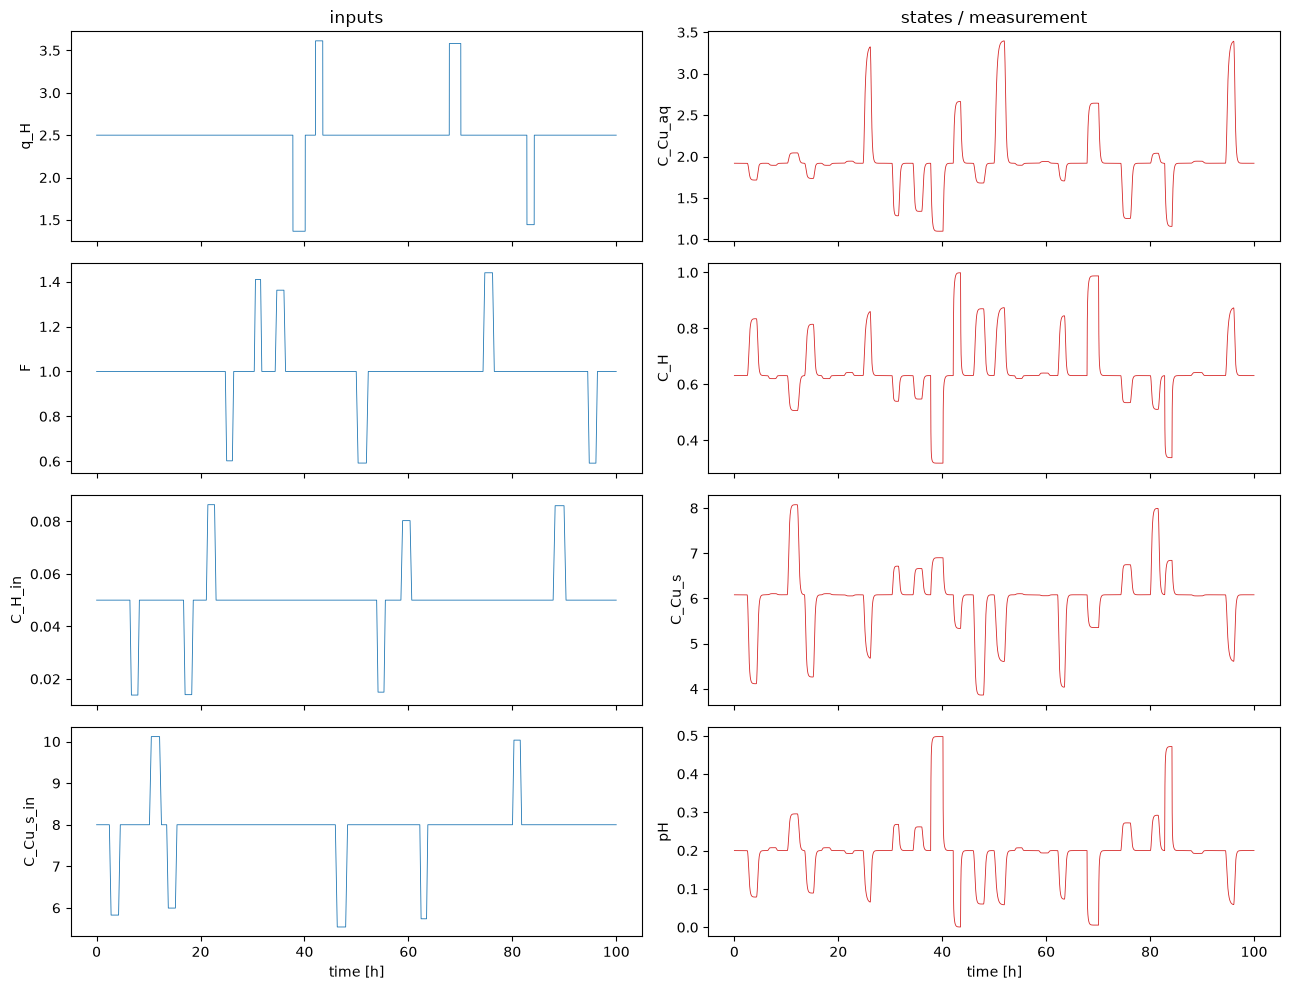

In [5]:
# Plot inputs (left) and states / measurement (right)
t_h = t_min / 60.0
fig, ax = plt.subplots(4, 2, figsize=(13, 10), sharex=True)
for a, n in zip(ax[:, 0], ["q_H", "F", "C_H_in", "C_Cu_s_in"]):
    a.plot(t_h, vectors[n], lw=0.6); a.set_ylabel(n)
for a, (v, lab) in zip(ax[:, 1], [(C_Cu_aq, "C_Cu_aq"), (C_H, "C_H"), (C_Cu_s, "C_Cu_s"), (pH(C_H), "pH")]):
    a.plot(t_h, v, lw=0.6, color="tab:red"); a.set_ylabel(lab)
ax[0, 0].set_title("inputs"); ax[0, 1].set_title("states / measurement")
ax[-1, 0].set_xlabel("time [h]"); ax[-1, 1].set_xlabel("time [h]")
fig.tight_layout()